# 03 — Clustering with K-means

**Goal:** let the data reveal natural groups of customers, instead of cutting them into arbitrary equal-sized groups like the classic RFM scores do.

Steps:
1. Prepare the features (log transformation + standardization)
2. Choose the number of segments *k* (elbow method + silhouette score)
3. Run K-means
4. Profile and interpret the segments
5. Compare with the classic RFM scores

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_DIR = Path("../data")
RANDOM_STATE = 42   # makes results reproducible

rfm = pd.read_csv(DATA_DIR / "rfm.csv", index_col="Customer ID")
print(f"{len(rfm):,} customers")
rfm.head()

5,839 customers


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
Customer ID,,,,,,,
12346,530,2,169.36,1,2,1,4
12347,3,8,4921.53,5,4,5,14
12348,76,5,1658.40,3,4,4,11
12349,19,3,3678.69,5,3,5,13
12350,311,1,294.40,2,1,2,5


## 1. Preparing the features

Two transformations, each with a specific purpose:

- **Log** (`log1p`): compresses the giants, as seen in notebook 02.
- **Standardization** (`StandardScaler`): puts the three metrics on the same scale (mean 0, standard deviation 1). Without it, Monetary (values in the thousands) would weigh far more in the distance calculation than Frequency (values around 1 to 100), simply because of its units.

In [16]:
features = ["Recency", "Frequency", "Monetary"]

X_log = np.log1p(rfm[features])
scaler = StandardScaler()
X = scaler.fit_transform(X_log)

pd.DataFrame(X, columns=features).describe().round(2)

,Recency,Frequency,Monetary
count,5839.00,5839.00,5839.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-2.47,-1.06,-3.94
25%,-0.77,-1.06,-0.71
50%,0.07,-0.20,-0.03
75%,0.96,0.66,0.66
max,1.40,5.42,4.70


Each column now has a mean of 0 and a standard deviation of 1.

## 2. Choosing the number of segments

K-means needs to be told how many groups to find. We test *k* from 2 to 10 with two complementary methods:

- **Elbow method** — *inertia* measures how tightly packed the clusters are (lower is better). It always decreases as *k* grows, so we look for the "elbow" where adding a segment stops helping much.
- **Silhouette score** — measures how well each customer fits its own cluster compared to the nearest other cluster (from -1 to 1, higher is better).

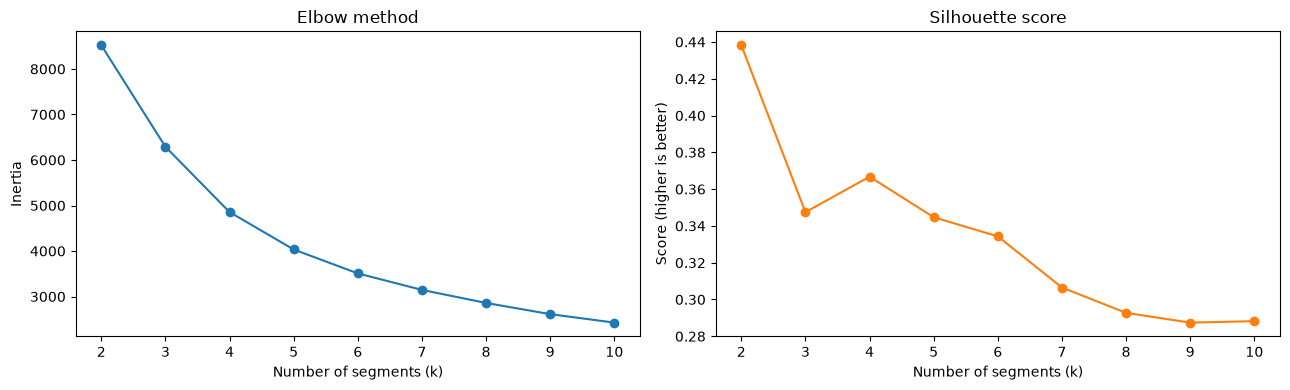

In [17]:
k_values = range(2, 11)
inertias, silhouettes = [], []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of segments (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_values, silhouettes, marker="o", color="tab:orange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of segments (k)")
axes[1].set_ylabel("Score (higher is better)")
plt.tight_layout()
plt.show()

In [18]:
pd.DataFrame({"k": list(k_values), "Inertia": inertias,
              "Silhouette": silhouettes}).round(3)

,k,Inertia,Silhouette
0,2,8522.021,0.438
1,3,6290.533,0.347
2,4,4855.540,0.367
3,5,4034.056,0.345
4,6,3508.186,0.334
5,7,3145.432,0.307
6,8,2859.111,0.293
7,9,2613.261,0.287
8,10,2426.753,0.288


**Choosing k.** The best *k* is a balance between the two charts **and business usefulness**: 2 segments is often the best mathematically but too coarse to act on, while 8 segments is too many for a marketing team to manage.

We start with **k = 4** — a common, actionable choice. *If the charts point clearly elsewhere, change `K` below and re-run the following cells.*

In [19]:
K = 4

## 3. Running K-means

In [20]:
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
raw_labels = kmeans.fit_predict(X)

# K-means numbers clusters arbitrarily. We renumber them from
# lowest to highest average spending, so that 0 = least valuable.
order = (pd.Series(rfm["Monetary"].values).groupby(raw_labels).mean()
         .sort_values().index)
relabel = {old: new for new, old in enumerate(order)}
rfm["Cluster"] = pd.Series(raw_labels).map(relabel).values

print(f"Silhouette score for k={K}: {silhouette_score(X, raw_labels):.3f}")
rfm["Cluster"].value_counts().sort_index()

Silhouette score for k=4: 0.367


Cluster
0    1957
1    1261
2    1440
3    1181
Name: count, dtype: int64

## 4. Profiling the segments

The key table of the project: what does a typical customer in each segment look like? We use the **median** for each metric (less sensitive to extreme customers than the mean), plus each segment's share of customers and of revenue.

In [21]:
profile = rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Recency_median=("Recency", "median"),
    Frequency_median=("Frequency", "median"),
    Monetary_median=("Monetary", "median"),
    Revenue=("Monetary", "sum"),
)
profile["% customers"] = (profile["Customers"] / profile["Customers"].sum() * 100).round(1)
profile["% revenue"] = (profile["Revenue"] / profile["Revenue"].sum() * 100).round(1)
profile.drop(columns="Revenue").round(1)

,Customers,Recency_median,Frequency_median,Monetary_median,% customers,% revenue
Cluster,,,,,,
0,1957,402.0,1.0,269.4,33.5,3.7
1,1261,24.0,3.0,712.8,21.6,6.4
2,1440,185.0,4.0,1443.4,24.7,16.2
3,1181,17.0,13.0,4862.5,20.2,73.7


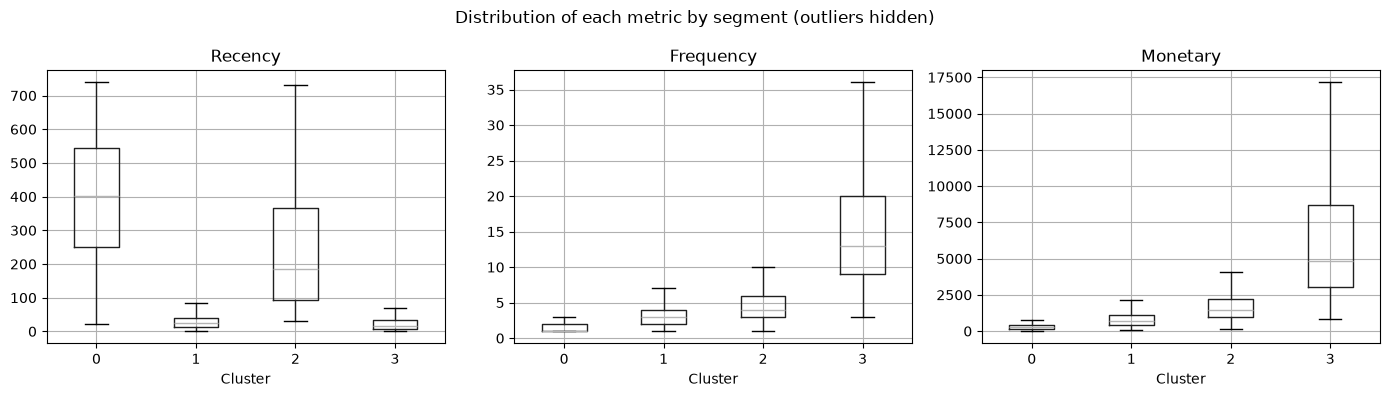

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, features):
    rfm.boxplot(column=col, by="Cluster", ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("Cluster")
plt.suptitle("Distribution of each metric by segment (outliers hidden)")
plt.tight_layout()
plt.show()

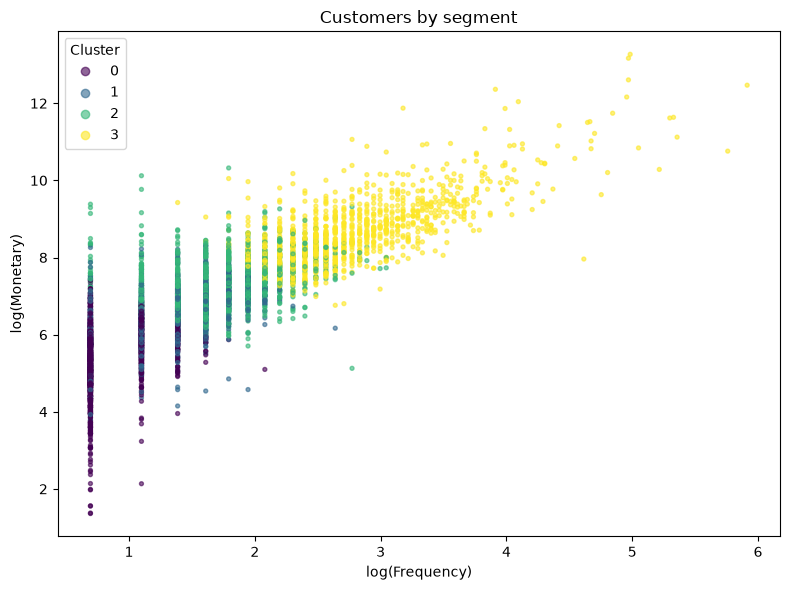

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_log["Frequency"], X_log["Monetary"],
                     c=rfm["Cluster"], cmap="viridis", s=8, alpha=0.6)
ax.set_xlabel("log(Frequency)")
ax.set_ylabel("log(Monetary)")
ax.set_title("Customers by segment")
ax.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

### Naming the segments

Each segment is named after its typical customer's profile — how recently, how often and how much they buy:

- **Lost** — a single purchase, more than a year ago.
- **Promising** — bought recently, but only a few orders so far. *We don't know their first purchase date, so we can't say they are new — only that they are active.*
- **At risk** — valuable customers (4 orders, ~£1,400) who haven't returned in about 6 months, not even for the 2011 holiday season. The data shows *that* they left, not *why*.
- **Champions** — frequent, recent and high-spending: about 20% of customers generating about 74% of revenue.

In [24]:
SEGMENT_NAMES = {
    0: "Lost",        # one purchase, over a year ago
    1: "Promising",   # recent activity, few orders so far
    2: "At risk",     # good customers who haven't returned in ~6 months
    3: "Champions",   # frequent, recent, high spending: ~74% of revenue
}
rfm["Segment"] = rfm["Cluster"].map(SEGMENT_NAMES)
rfm["Segment"].value_counts()

Segment
Lost         1957
At risk      1440
Promising    1261
Champions    1181
Name: count, dtype: int64

## 5. Comparison with the classic RFM scores

Do the K-means segments agree with the traditional scores from notebook 02? If each segment covers a distinct range of scores, both methods tell a consistent story — but K-means found the boundaries from the data rather than from arbitrary cut-offs.

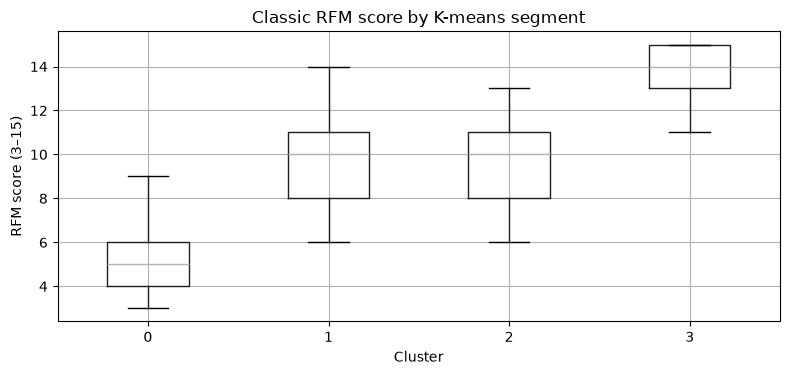

In [25]:
rfm.boxplot(column="RFM_score", by="Cluster", figsize=(8, 4))
plt.title("Classic RFM score by K-means segment")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("RFM score (3–15)")
plt.tight_layout()
plt.show()

In [26]:
pd.crosstab(rfm["RFM_score"], rfm["Cluster"])

Cluster,0,1,2,3
RFM_score,,,,
3,308,0,0,0
4,491,0,0,0
5,498,0,0,0
6,400,59,19,0
7,209,125,124,0
8,48,185,238,0
9,3,214,280,0
10,0,197,263,0
11,0,210,265,3


## 6. Checking a hypothesis: the holiday shoppers

In notebook 02, log(Recency) showed a large peak around 400 days. Hypothesis: customers who shopped for the 2010 holidays and never came back. We check the month of their last purchase.

Customers with a recency of 350–450 days: 769


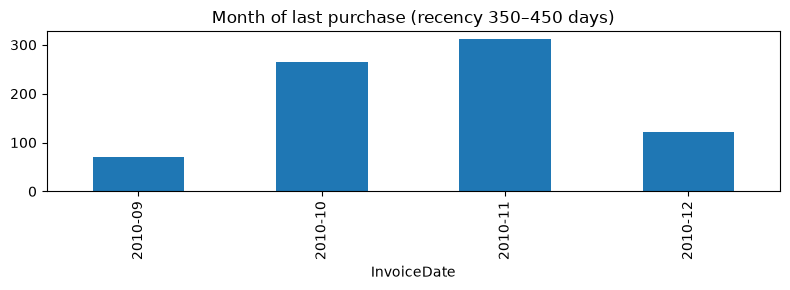

In [27]:
df = pd.read_csv(DATA_DIR / "online_retail_clean.csv", parse_dates=["InvoiceDate"])
last_purchase = df.groupby("Customer ID")["InvoiceDate"].max()

peak = rfm[(rfm["Recency"] >= 350) & (rfm["Recency"] <= 450)].index
print(f"Customers with a recency of 350–450 days: {len(peak):,}")

(last_purchase.loc[peak].dt.to_period("M")
 .value_counts().sort_index()
 .plot(kind="bar", figsize=(8, 3), title="Month of last purchase (recency 350–450 days)"))
plt.tight_layout()
plt.show()

## 7. Saving

In [28]:
rfm.to_csv(DATA_DIR / "rfm_segments.csv")
print("Saved:", DATA_DIR / "rfm_segments.csv")

Saved: ..\data\rfm_segments.csv


## Next step

Write up the findings (README), then build an interactive demo with Streamlit.